In [1]:
# This cell does not render in the docs because it has a `remove-cell` tag.
import warnings

warnings.filterwarnings("ignore")

# A chemical map of British Bronze Age axes

## The Bronze Age in Britain

Around 2400 BC, metal tools began to appear across the British Isles. Over the next millennium and a half, communities learned to mine copper, to alloy it with tin into the harder, tougher material we call bronze, and to cast that bronze into tools, weapons, and ornaments. This stretch of time, roughly 2400 to 800 BC, is the British Bronze Age. It draws to a close when ironworking takes over.

Of everything Bronze Age people made, the axe is the most abundant and the most telling. It was the everyday workhorse, used to fell trees, shape timber, and clear ground. But it was also a thing of value: hoarded, exchanged, and sometimes placed deliberately in rivers and bogs. Because axes were made continuously for 1,500 years and their shapes drifted steadily over that time, archaeologists treat them as a kind of clock, where the form of an axe is a rough guide to when it was made.

Here we ask a simple question. Each axe has a chemical composition, the proportions of metals it contains. If we let UMAP arrange the axes by that composition alone, will the arrangement rediscover the history we already know? And might it show us something we would otherwise miss?

## How an axe changed over 15 centuries

The axe did not stay still. The earliest smiths cast a flat or lightly flanged wedge of metal and lashed it to a wooden handle, or haft; the flanges were just low ridges raised along the edges. Over time they raised those flanges higher and added a transverse stop-ridge to keep the haft from splitting, producing the palstave of the middle centuries. Later still they cast a hollow socket directly into the head so the haft could slot inside, giving the socketed axe of the final Bronze Age. The three finds below sketch that journey from left to right, lining up with the three broad ages that organize everything to come: Early, Middle, and Late.

<div style="display:flex; gap:18px; align-items:flex-start; text-align:center; margin-top:8px;">
  <figure style="margin:0; flex:1;">
    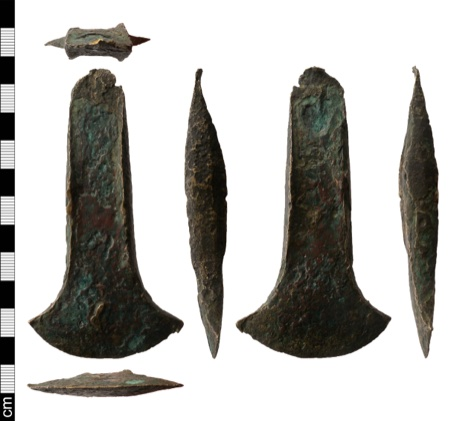
    <figcaption style="font-size:0.85em;">Early Bronze Age flanged axe<br><span style="color:#666;">PAS / British Museum, <a href="https://commons.wikimedia.org/wiki/File:Bronze_Age_Flanged_Axehead_(FindID_502930).jpg">CC BY-SA 4.0</a></span></figcaption>
  </figure>
  <figure style="margin:0; flex:1;">
    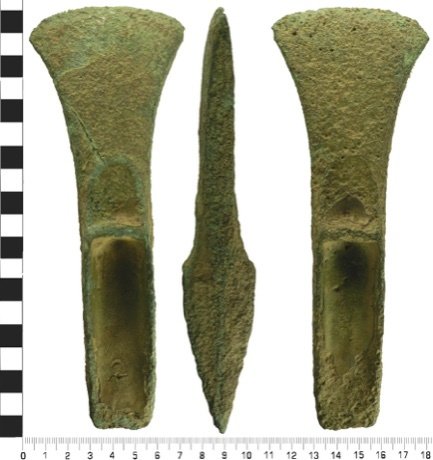
    <figcaption style="font-size:0.85em;">Middle Bronze Age palstave<br><span style="color:#666;">PAS / British Museum, <a href="https://commons.wikimedia.org/wiki/File:Bronze_age_palstave_axe_(FindID_491854).jpg">CC BY-SA 2.0</a></span></figcaption>
  </figure>
  <figure style="margin:0; flex:1;">
    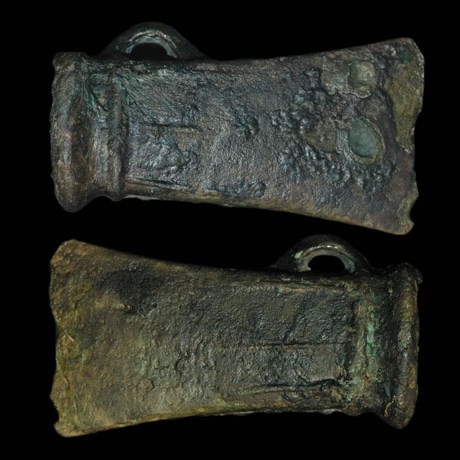
    <figcaption style="font-size:0.85em;">Late Bronze Age socketed axe<br><span style="color:#666;">F. Fabianski, <a href="https://commons.wikimedia.org/wiki/File:011897British_Bronze_Age_%27Looped_%26_Socketed%27_Axe.jpg">public domain</a></span></figcaption>
  </figure>
</div>

## The dataset

The data come from a remarkable resource, a catalog of British Bronze Age axes assembled by Bevan and colleagues and published through the Archaeology Data Service ([Bevan et al., 2024](https://doi.org/10.5284/1122315)). It gathers more than a century of museum study and metal-detector finds into one place, and, crucially, it pairs each axe with a laboratory measurement of its composition — how much copper, tin, lead, arsenic, and a dozen other elements it contains.

In [2]:
import urllib.request
import zipfile
from pathlib import Path

# The catalogue tables and photographs were repackaged into a single archive for
# this example, hosted at the URL below. The archive's provenance/SOURCES.md
# records the credits and licences for everything inside it.
BUNDLE_URL = "https://raw.githubusercontent.com/Arcadia-Science/glass-box-umap/main/docs/examples/bronze_axes_bundle.zip"


def _download_axes_bundle() -> Path:
    bundle_dir = Path("bronze_axes_bundle")
    if not bundle_dir.exists():
        archive = Path("bronze_axes_bundle.zip")
        if not archive.exists():
            urllib.request.urlretrieve(BUNDLE_URL, archive)
        with zipfile.ZipFile(archive) as zf:
            zf.extractall(".")
    return bundle_dir


bundle = _download_axes_bundle()

## First we need clean data

The catalog reports more than 20 elements, but most were detected in only a handful of axes. UMAP needs the same measurements present for every axe, so we face a trade-off — keep many elements and few axes, or many axes and few elements.

We strike a compromise, keeping the 10 elements measured broadly across the corpus, discarding the analyses flagged as unreliable, and dropping any axe still missing one of those 10. What survives is a smaller table with no gaps.

In [3]:
import pandas as pd

elemental = pd.read_csv(bundle / "data" / "ADS_earlyaxes_elemental.tsv", sep="\t")
all_elements = ["Cu", "Sn", "Pb", "As", "Sb", "Ag", "Ni", "Fe", "Co", "Bi",
                "Zn", "Au", "S", "Mn", "Al", "Si", "Mg", "Cd", "In", "Te", "W"]
coverage = {e: pd.to_numeric(elemental[e], errors="coerce").notna().mean()
            for e in all_elements if e in elemental.columns}
print("fraction of analyses that report each element:")
for e, frac in sorted(coverage.items(), key=lambda kv: -kv[1]):
    print(f"  {e}: {frac:.0%}")

keep_elements = ["Cu", "Sn", "As", "Sb", "Pb", "Ag", "Ni", "Fe", "Co", "Bi"]
for e in keep_elements:
    elemental[e] = pd.to_numeric(elemental[e], errors="coerce")

drop_flags = {"PersistentHarmonisationProblem", "CorrosionProductOnly"}
unflagged = elemental[~elemental["AnalysisFlags"].fillna("").apply(
    lambda s: any(f in s for f in drop_flags))]
complete = unflagged.dropna(subset=keep_elements)

print(f"\nraw analyses in the catalogue:        {len(elemental)}")
print(f"after dropping unreliable analyses:   {len(unflagged)}")
print(f"after requiring all ten elements:     {len(complete)}"
      f"  ({complete['ArtefactID'].nunique()} distinct axes)")

fraction of analyses that report each element:
  As: 98%
  Sb: 95%
  Ag: 95%
  Ni: 94%
  Pb: 94%
  Fe: 93%
  Sn: 91%
  Co: 84%
  Bi: 80%
  Cu: 64%
  Zn: 57%
  Au: 55%
  Mn: 27%
  Cd: 26%
  S: 14%
  Al: 1%
  Si: 1%
  In: 1%
  Te: 0%
  Mg: 0%
  W: 0%

raw analyses in the catalogue:        1316
after dropping unreliable analyses:   1314
after requiring all ten elements:     631  (539 distinct axes)


## Building the analysis table

Two steps remain. First, we attach each axe's published type from the catalog's main table, which stands in for its date. Second, we put the chemistry into a space fit for a distance-based method.

Because the 10 numbers for each axe are proportions of a single whole, raising one element must lower the rest, so comparing them directly is misleading. The standard remedy for compositional data is the centered log-ratio transform. We replace the occasional zero with a small positive value so the logarithm is defined, rescale each axe's 10 numbers to sum to one, and then re-express every element relative to that axe's own geometric average. A final standardization puts all 10 elements on a common scale so none dominates by sheer magnitude.

In [4]:
import numpy as np
from sklearn.preprocessing import StandardScaler

main = pd.read_csv(bundle / "data" / "ADS_earlyaxes_main.tsv", sep="\t", low_memory=False)
basic_type = main.drop_duplicates("ArtefactID").set_index("ArtefactID")["BasicType"]

aggregation = {element: "mean" for element in keep_elements}
aggregation["Laboratory"] = "first"
df = complete.groupby("ArtefactID", as_index=False).agg(aggregation)
df["BasicType"] = df["ArtefactID"].map(basic_type)

comp = df[keep_elements].to_numpy(dtype=float)
for j in range(comp.shape[1]):
    column = comp[:, j]
    column[column == 0] = column[column > 0].min() / 2.0
    comp[:, j] = column
comp = comp / comp.sum(axis=1, keepdims=True)
log_comp = np.log(comp)
clr = log_comp - log_comp.mean(axis=1, keepdims=True)

feature_cols = [f"clr_{e}" for e in keep_elements]
X = StandardScaler().fit_transform(clr)

print(f"{len(df)} axes (repeat analyses averaged), {len(feature_cols)} elements")
print("elements:", keep_elements)

df.head()

539 axes (repeat analyses averaged), 10 elements
elements: ['Cu', 'Sn', 'As', 'Sb', 'Pb', 'Ag', 'Ni', 'Fe', 'Co', 'Bi']


,ArtefactID,Cu,Sn,As,Sb,Pb,Ag,Ni,Fe,Co,Bi,Laboratory,BasicType
0,96,79.10,9.6,0.30000,0.30000,8.200000,0.30000,0.070000,0.100000,0.000,0.120000,unknown,Class 1
1,148,97.00,0.0,2.30000,0.49000,0.007000,0.28000,0.015000,0.005000,0.007,0.005000,British Museum,Class 2
2,150,88.50,11.6,0.16000,0.01000,0.090000,0.02500,0.012000,0.000000,0.003,0.000000,British Museum,Class 4
3,336,99.96,0.0,0.01000,0.02000,0.000000,0.01000,0.010000,0.000000,0.000,0.000000,unknown,Class 2
4,376,100.02,0.0,0.11465,0.19618,0.005096,0.15121,0.009936,0.008917,0.000,0.001274,British Museum,Class 2


## Ordering the axes by type

To ask whether the chemistry tracks time, we first put the axes in order. Their published types already form a sequence that archaeologists broadly agree on. The Early Bronze Age flat and flanged axes run from Class 1 through Class 5, the Middle Bronze Age palstaves from Group I through Group IV, and the socketed and continental forms follow. We use that sequence as our axis of time and group it into the three broad ages: the Early Bronze Age flat and flanged axes, the Middle Bronze Age palstaves, and the Late Bronze Age socketed axes.

:::{warning}
These types are a relative ordering, not calendar dates, and that is how the colors on the map are meant to be read. Forms overlap in production, some were long-lived, and an axe of an early type can be buried much later, so even among specialists the absolute dates of these stages stay approximate ([Needham et al. 1997](https://doi.org/10.1080/00665983.1997.11078784)). A sequence is what the typology supports cleanly, so a sequence is what we use.
:::

In [5]:
import re


def typo_stage(basic_type):
    if not isinstance(basic_type, str):
        return "unclassified"
    s = basic_type.strip()
    m = re.match(r"^Class\s+(\d)", s)
    if m:
        return f"Class {m.group(1)}"
    m = re.match(r"^Group\s+(IV|I{1,3})", s)
    if m:
        return f"Palstave {m.group(1)}"
    if s.rstrip("?").startswith("Late"):
        return "Late"
    if any(key in s for key in ("Flanged", "Transitional", "type")):
        return "Flanged/transitional"
    return "unclassified"


stage = df["BasicType"].apply(typo_stage)

STAGE_ORDER = ["Class 1", "Class 2", "Class 3", "Class 4", "Class 5",
               "Flanged/transitional", "Palstave I", "Palstave II",
               "Palstave III", "Palstave IV", "Late"]
AGE = {s: "Early" for s in STAGE_ORDER[:6]}
AGE.update({s: "Middle" for s in STAGE_ORDER[6:10]})
AGE["Late"] = "Late"

counts = stage.value_counts()
table = pd.DataFrame({
    "age": [AGE[s] for s in STAGE_ORDER],
    "stage": STAGE_ORDER,
    "n": [int(counts.get(s, 0)) for s in STAGE_ORDER],
})
print("axes per typological stage (relative order, earliest first):")
print(table.to_string(index=False))
print(f"\nunclassified (no usable type): {int(counts.get('unclassified', 0))}")

axes per typological stage (relative order, earliest first):
   age                stage   n
 Early              Class 1  13
 Early              Class 2  39
 Early              Class 3  83
 Early              Class 4  92
 Early              Class 5  97
 Early Flanged/transitional 123
Middle           Palstave I  22
Middle          Palstave II   7
Middle         Palstave III  31
Middle          Palstave IV   3
  Late                 Late  15

unclassified (no usable type): 14


## A chemical map with Glass Box UMAP

We fit Glass Box UMAP on the 10-element chemistry, color each axe by its typological stage, and look. Nothing about the typology went into building the layout, so any pattern that lines up with the type sequence is something the chemistry found on its own.

:::{tip}
Drag a box or lasso over any group of points and the bars on the right redraw to show which elements define that selection. That is the quickest way to ask the map what makes a region distinctive.
:::

In [6]:
from glass_box_umap import GlassBoxUMAP
from glass_box_umap.plotting import output_notebook, plot_embedding, show

gb_umap = GlassBoxUMAP(random_state=7, min_dist=1.0, quiet=True)
gb_umap.fit(X)
embedding = gb_umap.transform(X)
contributions = gb_umap.compute_contributions(X)

output_notebook(hide_banner=True)
show(
    plot_embedding(
        Z=embedding,
        contributions=contributions,
        group_names=stage.to_numpy(),
        feature_names=feature_cols,
        feature_values=X,
    )
)

## The island in the top left

One feature jumps out — a small cluster floating off in the top-left corner. Select it with the lasso tool and the top contribution on the bar plot is `clr_Sn`, which tells us tin is what drives the cluster. Switch to coloring by feature, choose `clr_Sn`, and hover over the points in the island: every one of these axes has very low tin content, if any at all. Almost all are the two earliest flat-axe types in Needham's scheme (Class 1 and Class 2), from the very beginning of metalworking in Britain.

This is the story of the Bronze Age in miniature. Tin is what makes bronze bronze: it is harder (materially) than copper, and easier to cast as well. These earliest axes carry essentially none. They are not really bronze at all but nearly pure copper, the work of the first metalworkers, from before the trick of adding tin took hold. The switch comes sharply. The next type, Class 3, is already full tin-bronze, placing the copper-to-bronze transition right at the Class 2–Class 3 boundary, within the Early Bronze Age rather than at its start. It's worth pointing out that the layout never saw the typology, yet from chemistry alone it set the pre-tin copper axes apart and, in effect, rediscovered the moment copper became bronze.

:::{admonition} Is this a data artifact?
:class: note
The axes in this cluster were measured by several laboratories and methods, and their analyses are complete, summing to essentially pure copper plus trace impurities. The pattern is just as strong among the best-documented British Museum measurements on their own. The missing tin is a property of the metal, not of how it was measured. One honest detail sits underneath the zeros: most of these readings are recorded as a flat zero, which for these older analyses means below the detection limit rather than literally no atoms. But with the rest of the metal already accounted for as near-pure copper, the axe was still never deliberately alloyed.
:::

axes on the island: 53
  type makeup: {'Class 2': 36, 'Class 1': 11, 'Class 3': 3, 'Flanged/transitional': 3}
  median tin on the island:    0.00%
  median tin everywhere else:  11.3%
  island axes under 1% tin:    53 of 53
  distinct labs on the island: 3

median tin by earliest Needham class (the copper-to-bronze switch):
  Class 1: median tin  0.00%  (n=13)
  Class 2: median tin  0.00%  (n=39)
  Class 3: median tin  9.60%  (n=83)
  Class 4: median tin 10.99%  (n=92)
  Class 5: median tin 12.86%  (n=97)


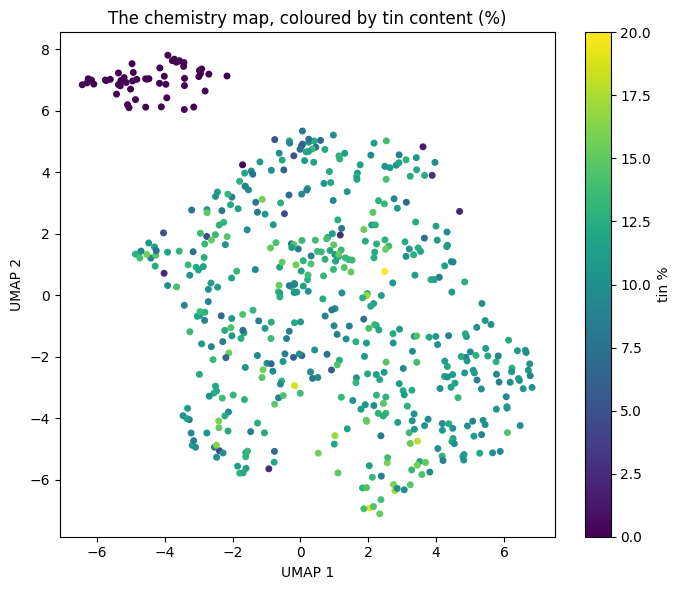

In [7]:
import matplotlib.pyplot as plt

tin_pct = df["Sn"].to_numpy()
island = (embedding[:, 0] < -1.5) & (embedding[:, 1] > 4.0)
print(f"axes on the island: {int(island.sum())}")
print(f"  type makeup: {pd.Series(stage.to_numpy()[island]).value_counts().to_dict()}")
print(f"  median tin on the island:    {np.nanmedian(tin_pct[island]):.2f}%")
print(f"  median tin everywhere else:  {np.nanmedian(tin_pct[~island]):.1f}%")
print(f"  island axes under 1% tin:    {int((tin_pct[island] < 1).sum())} of {int(island.sum())}")
print(f"  distinct labs on the island: {df.loc[island, 'Laboratory'].nunique()}")

print("\nmedian tin by earliest Needham class (the copper-to-bronze switch):")
axe_class = df["BasicType"].astype(str).str.extract(r"^(Class \d)")[0]
for c in ["Class 1", "Class 2", "Class 3", "Class 4", "Class 5"]:
    sel = (axe_class == c).to_numpy()
    if sel.any():
        print(f"  {c}: median tin {np.nanmedian(tin_pct[sel]):5.2f}%  (n={int(sel.sum())})")

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(embedding[:, 0], embedding[:, 1], c=np.clip(tin_pct, 0, 20), s=16, cmap="viridis")
ax.set(xlabel="UMAP 1", ylabel="UMAP 2", title="The chemistry map, coloured by tin content (%)")
fig.colorbar(sc, ax=ax, label="tin %")
fig.tight_layout()
plt.show()

## Putting faces to the points

Each point is a real object in a museum drawer. The British Museum publishes photographs of much of its collection under an open license, so for the axes it holds (about a fifth of the map) we can set the object beside its chemistry.

The plot below places those photographed axes back on the same map, colored by type. Selection and the contribution bars work as before, and hovering a point now brings up the axe itself. They fall across the whole map, so it stays a fair slice of the corpus.

In [8]:
import base64
import io
from pathlib import Path

import numpy as np
from PIL import Image

photo_dir = bundle / "axe_photos"
blank_pixel = "data:image/gif;base64,R0lGODlhAQABAAAAACH5BAEKAAEALAAAAAABAAEAAAICTAEAOw=="


def photo_uri(artefact_id):
    path = photo_dir / f"{artefact_id}.jpg"
    if not path.exists():
        return blank_pixel
    thumb = Image.open(path).convert("RGB")
    thumb.thumbnail((220, 220))
    buffer = io.BytesIO()
    thumb.save(buffer, format="jpeg", quality=80)
    return "data:image/jpeg;base64," + base64.b64encode(buffer.getvalue()).decode()


photo = [photo_uri(artefact_id) for artefact_id in df["ArtefactID"]]
has_photo = np.array([uri != blank_pixel for uri in photo])
print(f"photographed axes on the map: {int(has_photo.sum())} of {len(photo)}")

tooltip = """
<div style="max-width:240px">
  <img src="@photo" style="display:block; max-width:220px; max-height:220px; margin-bottom:4px"/>
  <span style="font-size:0.9em">@group &nbsp;&middot;&nbsp; tin @tin{0.0}% &nbsp;&middot;&nbsp; id @artefact</span>
</div>
"""

show(
    plot_embedding(
        Z=embedding[has_photo],
        contributions=contributions[has_photo],
        group_names=stage.to_numpy()[has_photo],
        feature_names=feature_cols,
        feature_values=X[has_photo],
        hover_tooltips=tooltip,
        hover_data={
            "photo": [uri for uri, keep in zip(photo, has_photo, strict=True) if keep],
            "tin": df["Sn"].to_numpy()[has_photo],
            "artefact": df["ArtefactID"].to_numpy()[has_photo],
        },
    )
)

photographed axes on the map: 121 of 539


## What the map shows

Starting from nothing but the elemental recipe of each axe, the map lays the Bronze Age out in front of us. Its boldest feature — the isolated island of earliest, tin-free, near-pure-copper axes — marks the very beginning of metal in Britain, the threshold the whole period is named for. Beyond that island the axes spread into a broad continuum rather than tidy compartments. Colored by typological stage, that continuum drifts gently along the sequence, the chemistry of axe metal shifting gradually from the earliest forms toward the latest rather than lurching in sudden steps.

The reason to do this with Glass Box UMAP is that none of it has to be taken on faith. Every feature of the map can be traced back to the elements that produced it, which is how we could say with confidence that the island is about tin rather than guessing from its position. It's a picture built from chemistry, one we can read back as chemistry, and one that turns out to retell history.